In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("house_data.csv")
df.head()

,area,Year,Rooms,Location,Price,Floor
0,87,1400,2,Marzdaran,1.392000e+10,7.0
1,98,1397,2,Kooy-e Ferdows,1.060000e+10,5.0
2,60,1396,1,Ebrahimabad,1.560000e+10,1.0
3,87,1394,2,Plan & Budget Organization,9.500000e+09,3.0
4,170,1375,3,Formaneya,3.400000e+11,2.0


In [5]:
df.columns

Index(['area', 'Year', 'Rooms', 'Location', 'Price', 'Floor'], dtype='str')

In [9]:
X = df[['area', 'Year', 'Rooms', 'Floor']]
y = df['Price']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
df.dtypes

area          int64
Year          int64
Rooms         int64
Location        str
Price       float64
Floor       float64
dtype: object

In [14]:
X = X.apply(pd.to_numeric, errors='coerce')

In [15]:
X = X.dropna()
y = y[X.index]

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 145270570144.33026
R2 Score: 0.05719647739573408


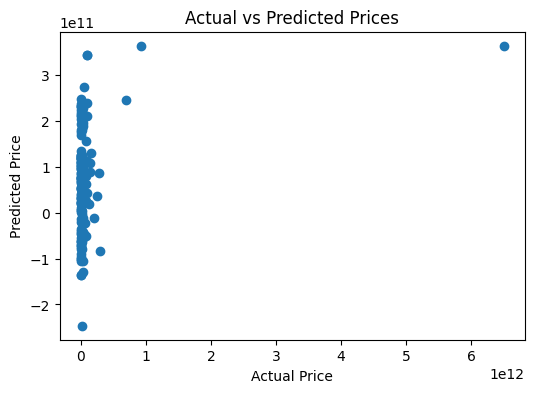

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.savefig("prediction_plot.png")
plt.show()

## 🔍 Key Insights

- The model predicts house prices based on area, rooms, year, and floor.
- There is a positive relationship between actual and predicted prices.
- Some variation exists, indicating model limitations.
- Model performance can be improved using more features (like location).